## Clean and Merge Data

In [40]:
import pandas as pd

# Step 1: Load the 311 complaints dataset
df = pd.read_csv("311 data.csv")

# Step 2: Keep only snow/ice removal related complaints
snow_keywords = [
    'Snow/Ice removal',
    'Sidewalk, Lack of Snow/Ice Removal',
    'Sidewalk,Lack of Snow/Ice Removal'
]
df = df[df['request_type_name'].isin(snow_keywords)].copy()

# Step 3: Convert and normalize complaint dates
df['create_date_utc'] = pd.to_datetime(df['create_date_utc'])
df['date'] = df['create_date_utc'].dt.normalize()

# Step 4: Load and clean daily weather data
weather_df = pd.read_csv("pittsburgh_weather_2015_2024.csv")
weather_df['date'] = pd.to_datetime(weather_df['date']).dt.tz_localize(None).dt.normalize()

weather_df = weather_df.rename(columns={
    'snowfall_sum': 'SNOW',
    'precipitation_sum': 'PRCP',
    'temperature_2m_max': 'TMAX',
    'temperature_2m_min': 'TMIN',
    'temperature_2m_mean': 'TAVG'
})

weather_df = weather_df[['date', 'SNOW', 'PRCP', 'TMAX', 'TMIN', 'TAVG']].fillna(0)

# Step 5: Merge complaints with weather by date
merged_df = df.merge(weather_df, on='date', how='left')

# Step 6: Fill missing weather values using previous day's values
merged_df = merged_df.sort_values(by='date')
weather_cols = ['SNOW', 'PRCP', 'TMAX', 'TMIN', 'TAVG']
merged_df[weather_cols] = merged_df[weather_cols].fillna(method='ffill')

# Step 7: Drop complaints with missing neighborhood
merged_df = merged_df.dropna(subset=['neighborhood'])

# Step 8: Clean and standardize text fields
merged_df['neighborhood'] = merged_df['neighborhood'].str.strip().str.title()
merged_df['request_type_name'] = merged_df['request_type_name'].fillna('').str.strip()

# Step 9: Extract time features
merged_df['date'] = pd.to_datetime(merged_df['date'])
merged_df['weekday'] = merged_df['date'].dt.day_name()
merged_df['is_weekend'] = merged_df['date'].dt.weekday >= 5
merged_df['year'] = merged_df['date'].dt.year
merged_df['month'] = merged_df['date'].dt.month

# Step 10: Remove fully empty rows and duplicates
merged_df = merged_df.dropna(how='all')
merged_df = merged_df.drop_duplicates()

# Step 11: Load and process traffic sensor data
traffic_df = pd.read_csv("Traffic_Data.csv")
traffic_df = traffic_df.dropna(subset=['average_daily_car_traffic'])
traffic_df['count_start_date'] = pd.to_datetime(traffic_df['count_start_date'])
traffic_df = traffic_df[(traffic_df['count_start_date'].dt.year >= 2017) & (traffic_df['count_start_date'].dt.year <= 2021)]

# Calculate yearly average daily traffic
traffic_df['year'] = traffic_df['count_start_date'].dt.year

yearly_avg = traffic_df.groupby(['neighborhood', 'year']).agg(
    total_traffic=('average_daily_car_traffic', 'sum'),
    days_with_data=('average_daily_car_traffic', 'count')
).reset_index()

yearly_avg['yearly_avg_daily_traffic'] = yearly_avg['total_traffic'] / yearly_avg['days_with_data']

# Average over 5 years (2017–2021) for each neighborhood
final_avg_traffic = yearly_avg.groupby('neighborhood')['yearly_avg_daily_traffic'].mean().reset_index()
final_avg_traffic = final_avg_traffic.rename(columns={'yearly_avg_daily_traffic': 'avg_daily_car_traffic_2017_2021'})

# Step 12: Load neighborhood area data
area_df = pd.read_csv("Neighborhood_Area.csv")
area_df = area_df.rename(columns={'hood': 'neighborhood'})

# Step 13: Merge datasets
final_df = merged_df.merge(final_avg_traffic, on='neighborhood', how='left')
final_df = final_df.merge(area_df[['neighborhood', 'sqmiles']], on='neighborhood', how='left')

# Step 14: Select only useful columns
final_df = final_df[[
    'date', 'neighborhood', 'SNOW', 'PRCP', 'TMAX', 'TMIN', 'TAVG',
    'weekday', 'is_weekend', 'year', 'month',
    'avg_daily_car_traffic_2017_2021', 'sqmiles'
]]

# Step 15: Save the final cleaned dataset
final_df.to_csv("snow_removal_final_clean.csv", index=False)


/var/folders/m1/5sn897yx2115rkyv82ngwhjm0000gn/T/ipykernel_64981/1492526938.py:38: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df[weather_cols] = merged_df[weather_cols].fillna(method='ffill')


## Feature Engineering

In [42]:
# Load the cleaned final dataset
final_df = pd.read_csv("snow_removal_final_clean.csv")

# Step 1: Aggregate to get daily request counts per neighborhood
daily_counts = final_df.groupby(['neighborhood', 'date']).size().reset_index(name='daily_request_count')

# Step 2: Merge back weather and area features
weather_area_cols = ['date', 'neighborhood', 'SNOW', 'PRCP', 'TMAX', 'TMIN', 'TAVG',
                     'weekday', 'is_weekend', 'year', 'month',
                     'avg_daily_car_traffic_2017_2021', 'sqmiles']
daily_counts = daily_counts.merge(final_df[weather_area_cols].drop_duplicates(), on=['date', 'neighborhood'], how='left')

# Step 3: Temporal Features
# Snow season (November to March)
daily_counts['is_snow_season'] = daily_counts['month'].isin([11, 12, 1, 2, 3]).astype(int)

# is_weekday already implied by is_weekend
if 'is_weekend' in daily_counts.columns:
    daily_counts['is_weekday'] = (~daily_counts['is_weekend']).astype(int)

# Step 4: Lag and Rolling Features
# Sort correctly
daily_counts = daily_counts.sort_values(['neighborhood', 'date'])

# Generate lag features
daily_counts['lag_1d'] = daily_counts.groupby('neighborhood')['daily_request_count'].shift(1)
daily_counts['lag_3d'] = daily_counts.groupby('neighborhood')['daily_request_count'].shift(3)

# Generate rolling features (mean and std over past 3 days)
daily_counts['rolling_mean_3d'] = daily_counts.groupby('neighborhood')['daily_request_count'].shift(1).rolling(window=3).mean().reset_index(0, drop=True)
daily_counts['rolling_std_3d'] = daily_counts.groupby('neighborhood')['daily_request_count'].shift(1).rolling(window=3).std().reset_index(0, drop=True)

# Step 5: Lag 1 year same week
# Extract week number
daily_counts['weekofyear'] = pd.to_datetime(daily_counts['date']).dt.isocalendar().week

# Compute weekly averages for each neighborhood-year-week
weekly_avg = daily_counts.groupby(['neighborhood', 'year', 'weekofyear'])['daily_request_count'].mean().reset_index()
weekly_avg = weekly_avg.rename(columns={'daily_request_count': 'weekly_avg_requests'})

# Create year_minus_1 for matching last year's data
daily_counts['year_minus_1'] = daily_counts['year'] - 1

# Merge lag_1y_same_week feature
daily_counts = daily_counts.merge(
    weekly_avg,
    left_on=['neighborhood', 'year_minus_1', 'weekofyear'],
    right_on=['neighborhood', 'year', 'weekofyear'],
    how='left',
    suffixes=('', '_lag1y')
)

# Rename and cleanup
daily_counts = daily_counts.rename(columns={'weekly_avg_requests': 'lag_1y_same_week'})
daily_counts = daily_counts.drop(columns=['year_lag1y'])

# Step 6: Save the feature engineered dataset
daily_counts.to_csv("snow_removal_feature_engineered.csv", index=False)


## Baseline and Feature Definition


Baseline Evaluation:
Lag-1d: MAE = 2.34, RMSE = 4.87
Rolling Mean 3d: MAE = 2.36, RMSE = 4.73
Lag-1y Same Week: MAE = 3.13, RMSE = 6.21


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


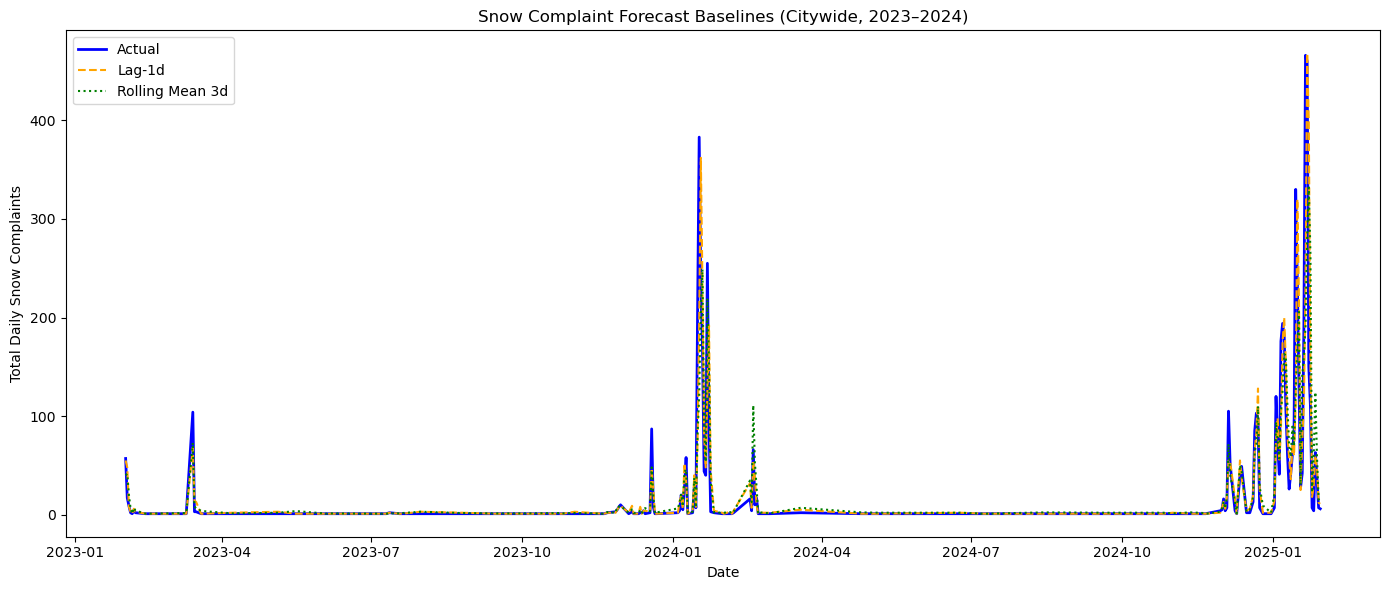

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Step 1: Load feature engineered dataset
data = pd.read_csv('snow_removal_feature_engineered.csv')
data['date'] = pd.to_datetime(data['date'])

# Step 2: Train-test split (80% train, 20% test)
split_date = data['date'].quantile(0.8)
train = data[data['date'] <= split_date]
test = data[data['date'] > split_date]

# Step 3: Baseline Evaluation Functions
def evaluate_baseline(y_true, y_pred, label):
    valid_idx = (~y_true.isna()) & (~y_pred.isna())
    y_true_valid = y_true[valid_idx]
    y_pred_valid = y_pred[valid_idx]
    mae = mean_absolute_error(y_true_valid, y_pred_valid)
    rmse = mean_squared_error(y_true_valid, y_pred_valid, squared=False)
    print(f"{label}: MAE = {mae:.2f}, RMSE = {rmse:.2f}")

# Step 4: Baselines
print("\nBaseline Evaluation:")
evaluate_baseline(test['daily_request_count'], test['lag_1d'], label='Lag-1d')
evaluate_baseline(test['daily_request_count'], test['rolling_mean_3d'], label='Rolling Mean 3d')
evaluate_baseline(test['daily_request_count'], test['lag_1y_same_week'], label='Lag-1y Same Week')

# Step 5: Baselines Plotting
# Aggregate citywide
test_citywide = test.groupby('date').agg({
    'daily_request_count': 'sum',
    'lag_1d': 'sum',
    'rolling_mean_3d': 'sum'
}).reset_index()

plt.figure(figsize=(14, 6))
plt.plot(test_citywide['date'], test_citywide['daily_request_count'], label='Actual', color='blue', linewidth=2)
plt.plot(test_citywide['date'], test_citywide['lag_1d'], label='Lag-1d', linestyle='--', color='orange')
plt.plot(test_citywide['date'], test_citywide['rolling_mean_3d'], label='Rolling Mean 3d', linestyle=':', color='green')

plt.title('Snow Complaint Forecast Baselines (Citywide, 2023–2024)')
plt.xlabel('Date')
plt.ylabel('Total Daily Snow Complaints')
plt.legend()
plt.tight_layout()
plt.show()

# Step 6: Feature Definitions
feature_definitions = {
    'date': 'Date of observation',
    'neighborhood': 'Neighborhood name',
    'daily_request_count': 'Target variable: number of snow-related 311 complaints',
    'SNOW': 'Snowfall (cm)',
    'PRCP': 'Precipitation (mm)',
    'TMAX': 'Maximum temperature (C)',
    'TMIN': 'Minimum temperature (C)',
    'TAVG': 'Average temperature (C)',
    'weekday': 'Day of the week',
    'is_weekend': '1 if Saturday/Sunday, else 0',
    'is_weekday': '1 if Monday-Friday, else 0',
    'month': 'Month of the year',
    'is_snow_season': '1 if month is Nov-Mar, else 0',
    'avg_daily_car_traffic_2017_2021': '5-year average daily car traffic',
    'sqmiles': 'Neighborhood area in square miles',
    'lag_1d': 'Daily request count 1 day ago',
    'lag_3d': 'Daily request count 3 days ago',
    'rolling_mean_3d': 'Mean of daily requests over past 3 days',
    'rolling_std_3d': 'Standard deviation of daily requests over past 3 days',
    'lag_1y_same_week': 'Same ISO week average complaints from previous year'
}

feature_df = pd.DataFrame(list(feature_definitions.items()), columns=['Feature', 'Definition'])
feature_df.to_csv('feature_definitions.csv', index=False)
